# Градиентный спуск (20 баллов)

## Основная часть (10 баллов)

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

np.random.seed(1234)
sns.set()
%config InlineBackend.figure_format = 'retina'

__Задача 1.__ Рассмотрим квадратичную задачу оптимизации:

$$ \min_{x \in \mathbb{R}^d} \left[f(x) := \frac{1}{2} x^\top A x - b^\top x\right], $$

где $A \in \mathbb{R}^{d \times d}$ такая, что $A$ — положительно определенная матрица, $b \in \mathbb{R}^d$.

__а) (2 балла)__ Докажите, что для константы сильной выпуклости верно $\mu \leq \frac{1}{2} \lambda_{\min} \left( A + A^\top \right)$, где $\lambda_{\min}(A)$ — минимальное собственное значение матрицы $A$.

#### Ваше решение (Markdown)

из семинаров известно что гессиан $ d^{2}f(x) = \frac{1}{2} * (A^{T} + A) $

из лекции известно что $ d^{2}f(x) \succ \mu * I $

то есть мы имеем $\frac{1}{2} * (A^{T} + A) \succ \mu * I $

Пусть вектор соответствующий собственному значению $ \lambda_{min} $ это $ t $

тогда 
$$t^{T}[\frac{1}{2} * (A^{T} + A) - \mu * I]t = t^{T} [\frac{1}{2} \lambda_{min} - \mu] t = [\frac{1}{2} \lambda_{min} - \mu] * |t|^{2} $$

$|t|^{2} -$ положительно

получается $\frac{1}{2}\lambda_{min} \geq \mu$

__б) (1 балла)__ Докажите, что для константы Липшица верно $L \geq \frac{1}{2}\lambda_{\max}\left(A + A^\top \right)$, где $\lambda_{\max}(A)$ — максимальное собственное значние матрицы $A$.

#### Ваше решение (Markdown)

по определению $L- $гладкости:

$ \forall x, y \in R^{d} \rightarrow | df(x) - df(y) | \leq L|x - y| $ 

подставим значение градиента в точках $x, y$

$ |\frac{1}{2} (A^{T} + A) [x - y]| \leq L|x - y| $

Пусть вектор соответствующий собственному значению $ \lambda_{max} $ это $ t $

Пусть $ x = t, y = 0 $

подставим эти значения в уравнение выше:

$ |\frac{1}{2} \lambda_{max} t| \leq L|t| $

получаем $ \frac{1}{2} \lambda_{max} \leq L $



Для упрощения задачи, _в последующих пунктах_ мы будем рассматривать только __симметричные__ матрицы $A$. Так как матрица $A$ симметрична, то $A + A^\top = 2A$. Тогда выполнено следующее равенство для соответствующих собственных чисел:
$$
\frac{1}{2} \lambda \left( A + A^\top \right) = \lambda (A).
$$

__в) (1.5 балла)__ Реализуйте функцию генерации квадратичной задачи по заданной размерности $d$ и константам сильной выпуклости $\mu$ и гладкости $L$. Для создания матрицы $A$ учтите, что ортогональные преобразования не изменяют собственные значения матрицы.

In [78]:
def generate_quadratic_problem(d, mu, L):
    """
    Генерирует квадратичную оптимизационную задачу:
    min_x f(x) = 0.5 * x^\top A x — b^\top x

    Параметры:
        d (int): Размерность задачи.
        mu (float): Константа сильной выпуклости (mu > 0).
        L (float): Константа гладкости (L > mu).

    Возвращает:
        A (np.array): Симметричная положительно определенная матрица размерности d x d.
        b (np.array): Вектор размерности d.
    """
    
    if mu <= 0 or L <= mu:
        raise ValueError("Условия mu > 0 и L > mu должны выполняться.")
    
    # YOUR CODE HERE

    lambda_array = np.random.uniform(low = mu, high = L, size = d)
    A = np.diag(lambda_array)
    b = np.random.rand(d, 1)
    return A, b

In [79]:
# Выполним проверку сгенерированной задачи при заданных параметрах
d = 50
mu = 1.0
L = 10.0

A, b = generate_quadratic_problem(d, mu, L)

# Проверка, что A симметрична
assert np.allclose(A, A.T), "Матрица A не симметрична."

# Проверка собственных значений A
eigenvalues_A = np.linalg.eigvalsh(A)
assert np.min(eigenvalues_A) >= mu, "Минимальное собственное значение A меньше mu."
assert np.max(eigenvalues_A) <= L, "Максимальное собственное значение A больше L."

__г) (0.5 балл)__ Докажите, что аналитическое решение квадратичной задачи имеет следующий вид:

$$ x^* = \left(\frac{A + A^\top}{2}\right)^{-1}b.$$

#### Ваше решение (Markdown)

из лекции известно что если $ f(x) -$  выпуклая, непрерывно дифференцируемая на $ R^{d} $ то

$ df(x^{*}) = 0 \Leftrightarrow x^{*}- $ глобальный минимум

Заметим что $df(x^{*}) = 0$

получается $ x^{*} -$ глобальный минимум, что является аналитическим решением нами поставленной задачи


Напишите код для вычисления $x^*$.

In [80]:
# Ваше решение (Code)

def x_min(A, b):
  return np.linalg.inv((A + A.T) /2) @ b

__Задача 2.__ В данной задаче мы рассмотрим поиск решения квадратичной задачи с помощью градиентного спуска.

__а) (0.5 балла)__ Реализуйте функцию подсчета градиента в заданной точке $x$ для функции $f(x)$.

In [81]:
def grad(x, A, b):
    """
    Вычисляет градиент квадратичной функции f(x) = 0.5 * x^T A x — b^T x.

    Параметры:
        x (np.array): Точка, в которой вычисляется градиент.
        A (np.array): Матрица квадратичной задачи.
        b (np.array): Вектор линейной части.

    Возвращает:
        grad (np.array): Градиент функции в точке x.
    """

    # YOUR CODE HERE

    return (1/2) * (A + A.T) @ x - b

__б) (0.5 балла)__ Для оценки сходимости мы будем использовать следующий критерий: $\| x - x^* \|_2$. Реализуйте функцию для подсчета данного критерия.

In [82]:
def criterion(x, x_star):
    """
    Вычисляет аргументный критерий сходимости: ||x - x*||_2.
    
    Параметры:
        x (np.array): Текущая точка.
        x_star (np.array): Точное решение.
    
    Возвращает:
        norm (float): Значение критерия.
    """

    # YOUR CODE HERE

    return np.linalg.norm(x - x_star)

__в) (4 балла)__  Реализуйте метод градиетного спуска.

**Псевдокод алгоритма**

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$.
- Начальная точка $x^0 \in \mathbb{R}^d$.
- Максимальное число итераций $K$.

---

$k$_-ая итерация:_

$$x^{k+1} = x^k - \gamma_k \nabla f \left(x^k\right).$$

---

**Условие остановки:**
- Достигнуто максимальное число итераций $K$ или $\| x^k - x^* \|_2 < \varepsilon$.

**Выход:**
- Полученное значение $x^K$.

In [83]:
def gradient_descent(A, b, grad, criterion, x_0, x_star, epsilon=1e-6, max_iter=1000, **params):
    """
    Реализация градиентного спуска для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы.
        b (np.array): Вектор линейной части.
        grad (Callable): Функция для вычисления градиента.
        criterion (Callable): Функция для вычисления критерия сходимости.
        x_0 (np.array): Начальная точка.
        x_star (np.array): Точное решение.
        epsilon (float): Точность сходимости (по умолчанию 1e-6).
        max_iter (int): Максимальное число итераций (по умолчанию 1000).
        **params: Именованные гиперпараметры метода
                  params['gamma'](k) - значение шага на итерации k (возможно, зависящее от аргумента).

    Возвращает:
        x (np.array): Найденное решение.
        errors (list): Список значений критерия сходимости на каждой итерации.
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]
    
    for k in range(max_iter):

        # YOUR CODE HERE

        x -= params["gamma"](k) * grad(x, A, b)

        error = criterion(x, x_star)
        errors.append(error)
        
        if error < epsilon:
            break
            
    return x, errors

Запустите градиентный спуск на $K = 10^3$ итераций с шагом $\gamma_k = \frac{1}{L}$ и начальной точкой $x^0 = 0$. Постройте сравнительный график зависимости точности метода $\|x^k - x^*\|_2$ и теоретической оценки от числа итераций.

In [84]:
# Ваше решение (Code)

x_0 = np.zeros([d, 1])
x_star = x_min(A, b)
gamma_k = lambda k : 1 / L
x_sol, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma = gamma_k)

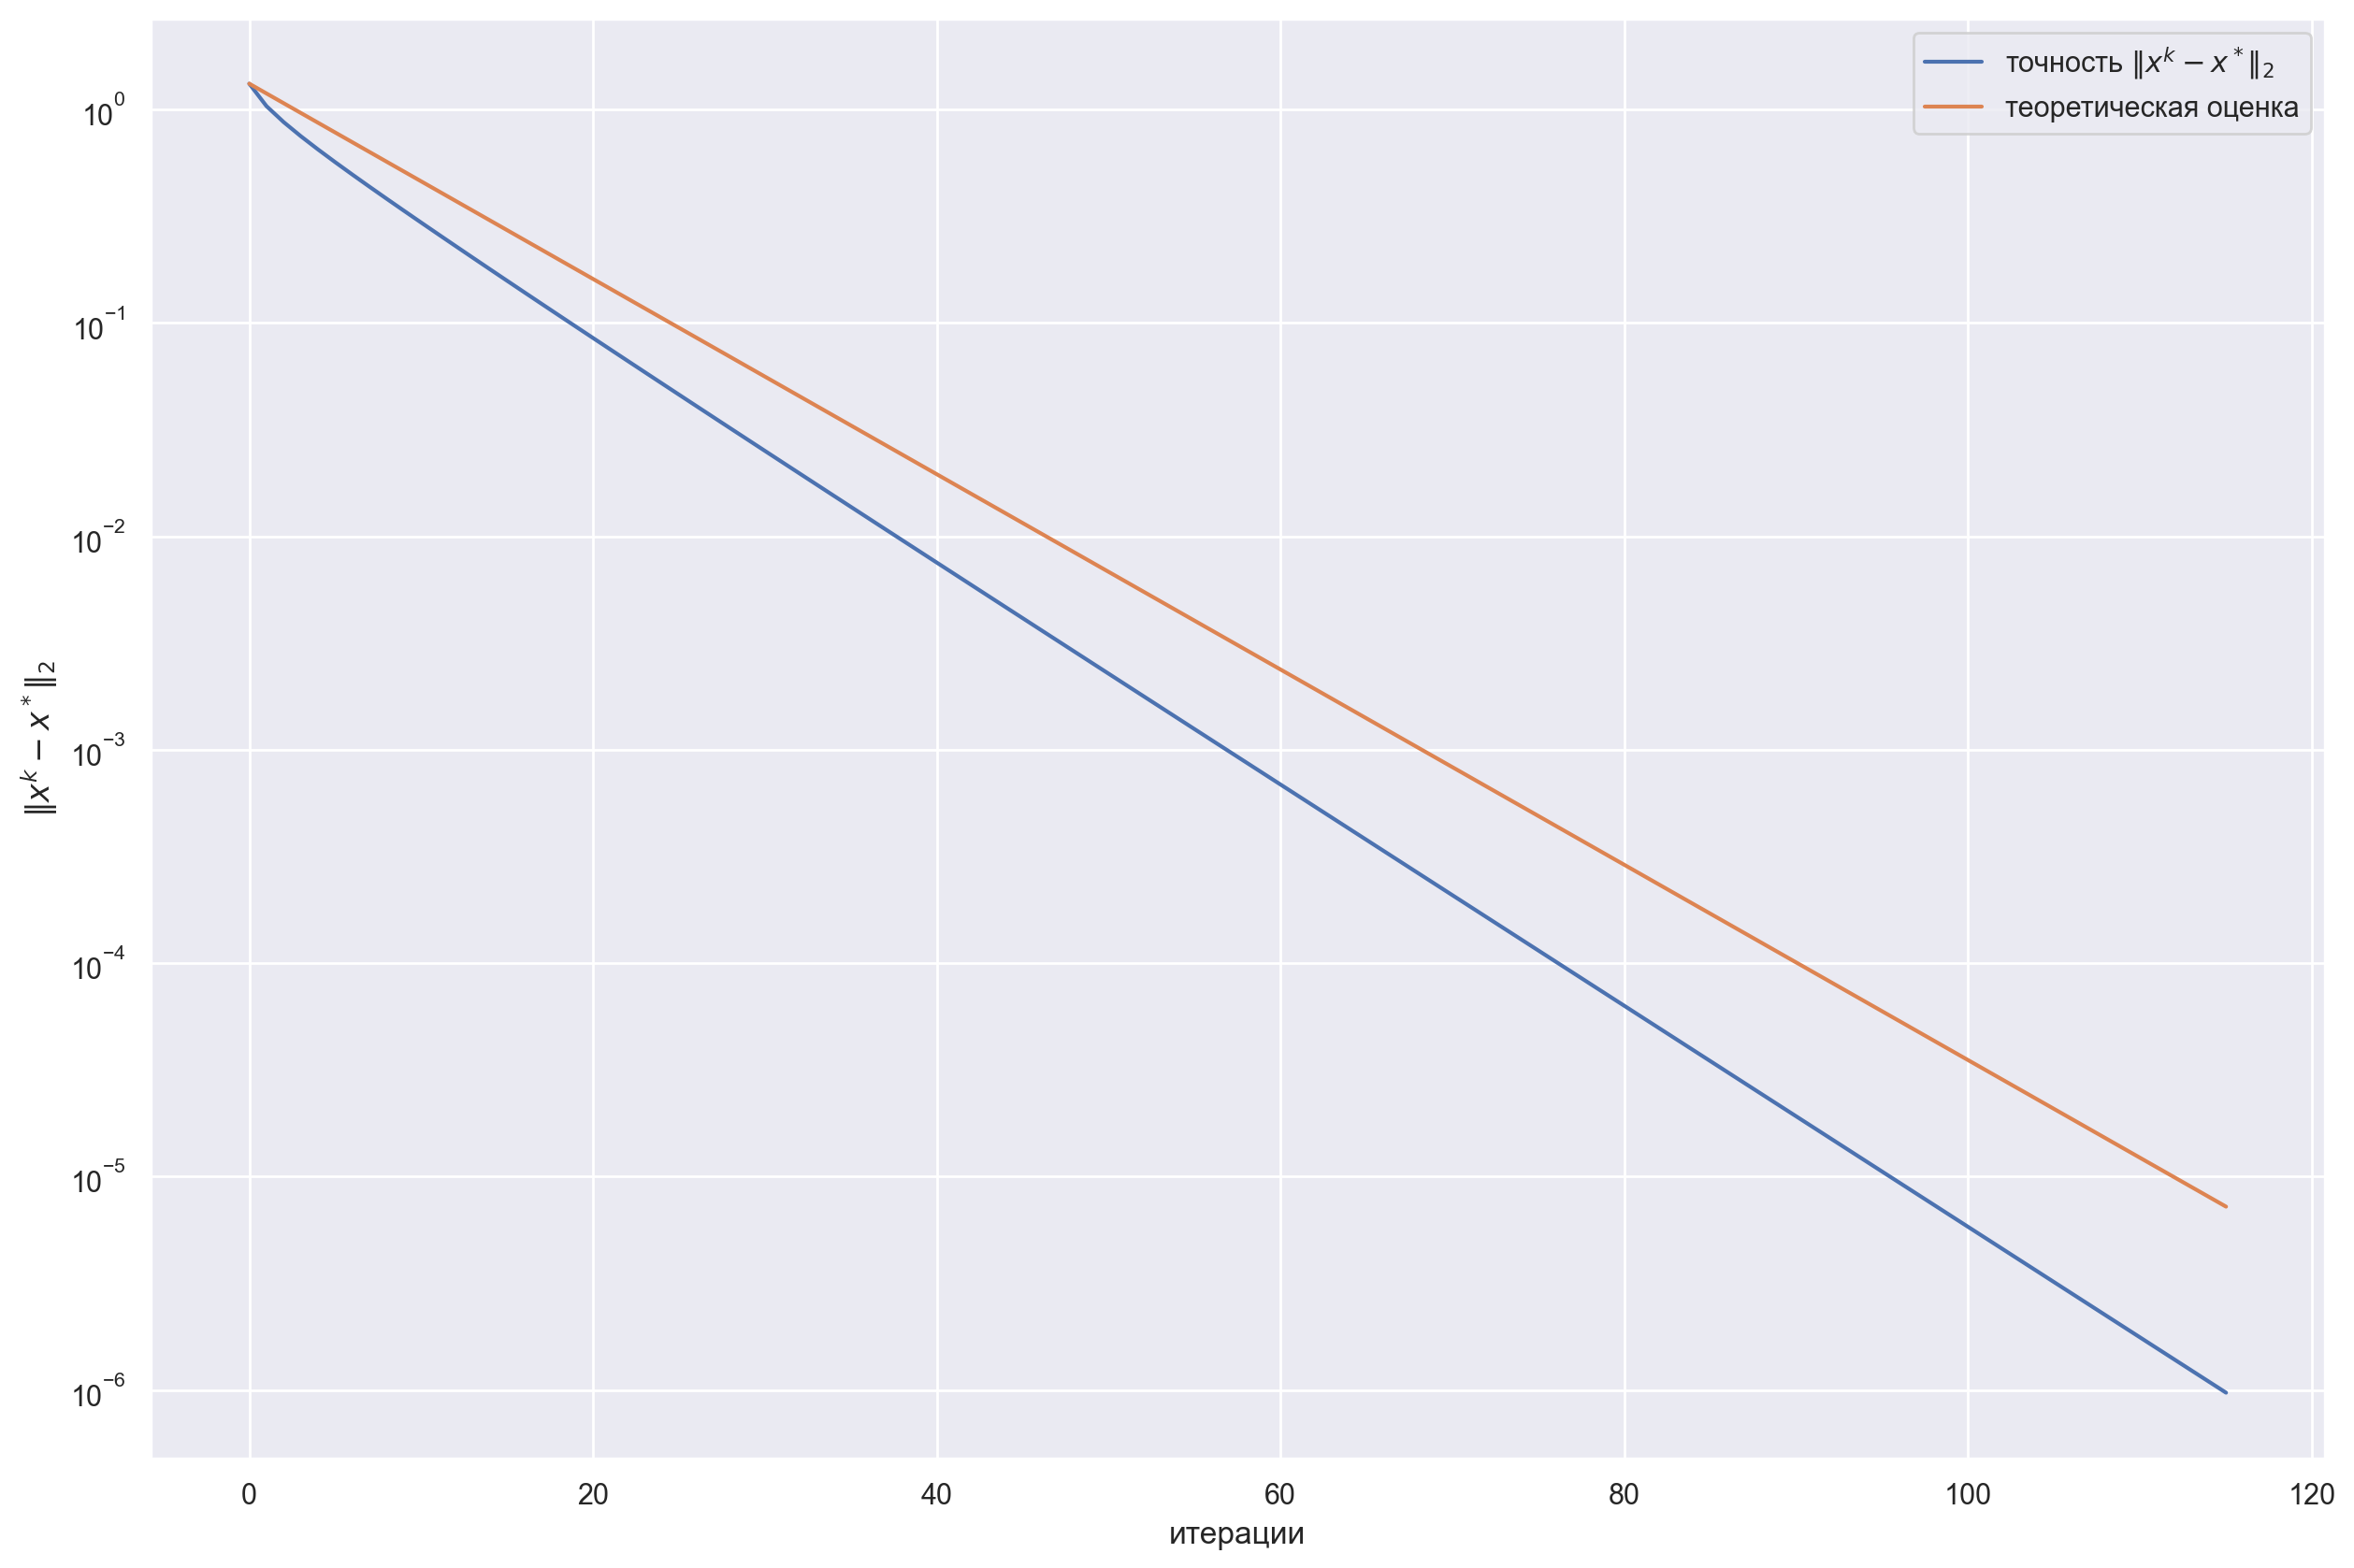

In [85]:
iter_count = len(errors)
grid = np.arange(iter_count)
speed = 1 - mu/L
start_error = errors[0]
top_score = [speed**k * start_error for k in range(iter_count)]


plt.figure(figsize = (15, 10))
plt.plot(grid, errors, label = r"точность $\|x^k - x^*\|_2$")
plt.plot(grid, top_score, label = "теоретическая оценка")
plt.xlabel("итерации")
plt.ylabel(r"$\|x^k - x^*\|_2$")
plt.legend()
plt.yscale("log")


верхняя оценка хоть и завышенная, но зато она довольно круче чем ее обычный аналог $(1 - \frac{4\mu^{2}}{L^{2}})$

## Дополнительная часть (10 баллов)

__Задача 3.__ Рассмотрим различные значения $\gamma_k$ и их влияние на сходимость градиентного спуска.

__а) (1 балл)__ Рассмотрите следующие значения шага:

1. $\gamma_k = \frac{1}{2L}$;

2. $\gamma_k = \frac{1}{L}$;

3. $\gamma_k = \frac{2}{L}$;

4. $\gamma_k = \frac{3}{L}$;

5. $\gamma_k = \frac{2}{\mu + L}$.

Проверьте, при каких значениях алгоритм сходится к решению. Нанесите на график те запуски, при которых наблюдается сходимость (теоретическую сходимость можно убрать).

In [86]:
# Ваше решение (Code)
gamma_list = [1/(2 * L), 1/L, 2/L, 3/L, 2/(L+mu)]
x_0_exp = np.zeros([d, 1])
x_star_exp = x_min(A, b)

for gamma in gamma_list:
  gamma_k_exp = lambda k : gamma
  x_sol_exp, errors_exp = gradient_descent(A, b, grad, criterion, x_0_exp, x_star_exp, gamma = gamma_k_exp)
  print(
    f"""
    для gamma = {gamma}
    точность решения : {np.round(errors_exp[-1], 3)}"
    количество итерации : {len(errors_exp)}
    """
  )


    для gamma = 0.05
    точность решения : 0.0"
    количество итерации : 238
    

    для gamma = 0.1
    точность решения : 0.0"
    количество итерации : 116
    

    для gamma = 0.2
    точность решения : 0.0"
    количество итерации : 148
    

    для gamma = 0.3
    точность решения : inf"
    количество итерации : 1001
    

    для gamma = 0.18181818181818182
    точность решения : 0.0"
    количество итерации : 61
    


/Users/aitore_04/Desktop/all_stuff/материалы мфти/4_курс/Метопты/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


На каком шаге получен наибыстрейший результат? Как думаете почему?

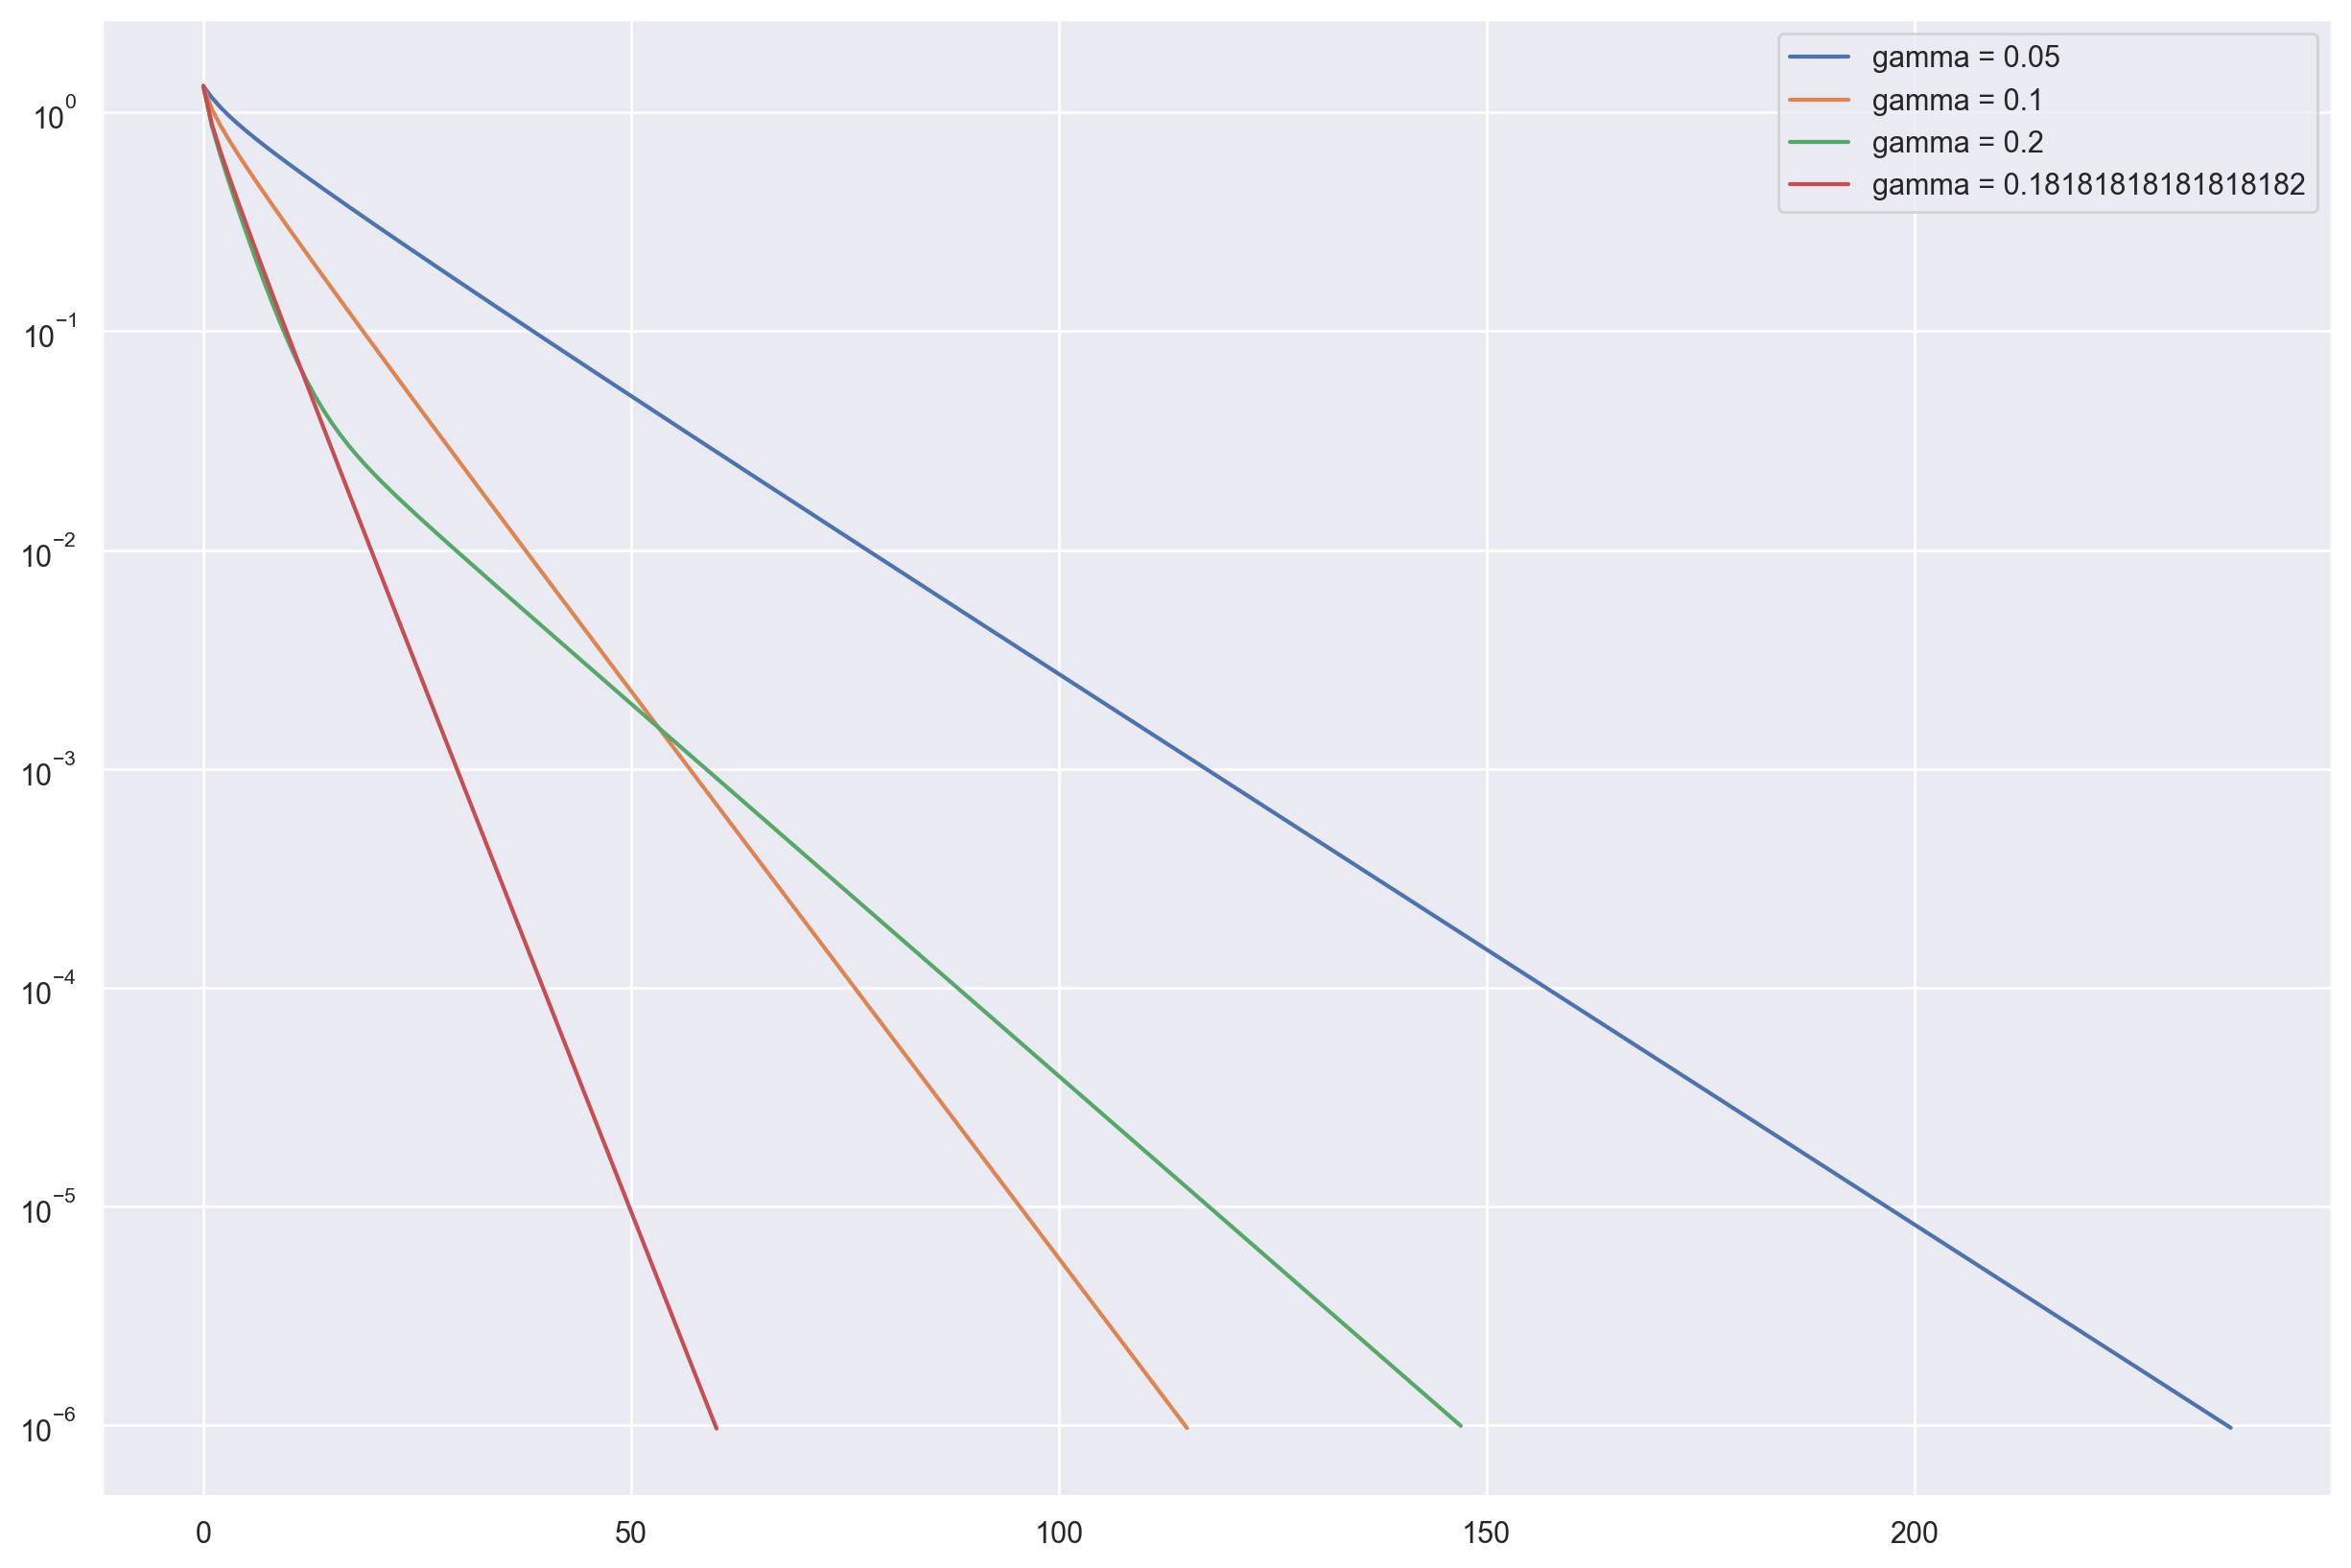

In [87]:
# Ваше решение (Code)
gamma_list = [1/(2 * L), 1/L, 2/L, 2/(L+mu)]
x_0_exp = np.zeros([d, 1])
x_star_exp = x_min(A, b)

plt.figure(figsize = (15, 10))

for gamma in gamma_list:
  gamma_k_exp = lambda k : gamma
  x_sol_exp, errors_exp = gradient_descent(A, b, grad, criterion, x_0_exp, x_star_exp, gamma = gamma_k_exp)
  iter_count = len(errors_exp)
  grid = np.arange(iter_count)
  plt.plot(grid, errors_exp, label = f"gamma = {gamma}")

plt.legend()
plt.yscale("log")

По моему мнению $ \frac{2}{\mu + L} $ учитывает своиства выпуклости и гладкости

константа $L$ описывает квадратичную функцию которая ограничивает изначальную, но $L$ может быть слишком большой и тогда шаг итерации будет слишком занижен. Поэтому константу можно уменьшить взяв среднее с $ \mu $

Получится как раз $ \frac{2}{\mu + L} $

__б) (2.5 балла)__ Рассмотрим значение шага $\gamma_k = \arg\min\limits_{\gamma} f \left(x_k - \gamma \nabla f \left(x^k\right) \right)$. Такая модификация называется методом наискорейшего спуска. Докажите, что 
$$
\gamma_k  = \frac{\langle \nabla f(x), \nabla f(x) \rangle}{\langle A \nabla f(x), \nabla f(x) \rangle} .
$$

#### Ваше решение (Markdown)

для простоты и буду иметь ввиду $ \nabla f(x_k) = \nabla f(x) = \nabla f $ и $x_k = x$. 

$f \left(x_k - \gamma \nabla f \left(x^k\right) \right) - $ одномерная функция от $ \gamma $.

Так же мы значем что $ f(x) = \frac{1}{2} x^\top A x - b^\top x $. Если подставить вместо $ x = x_k - \gamma \nabla f \left(x^k\right) $ то получим квадратичную функцию от $\gamma$

ее минимум будет в $ \gamma = \frac{x^\top A \nabla f(x) - b^\top \nabla f(x)}{\nabla f(x) A \nabla f(x)} =$

(она получилось по формуле $ -\frac{b}{2a} $ для квадратичного уравнения $ ax^{2} + bx + c $)

$ = \frac{(x^\top A - b^\top) \nabla f}{<A\nabla f, \nabla f >} $

Вспомним что по предположению $ A - $ симметричная.

Теперь заметим что $ \nabla f(x) = \frac{1}{2} (A\top + A)x - b = Ax - b $

получается $ \gamma = \frac{(x^\top A - b^\top) \nabla f}{<A\nabla f, \nabla f >} = \frac{<\nabla f, \nabla f>}{<A\nabla f, \nabla f >} $ что и требовалось доказать


__в) (2.5 балла)__ Реализуйте метод наискорейшего градиентного спуска. Для удобства предлагается немного изменить функцию градиентного спуска.

In [88]:
def fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, epsilon=1e-6, max_iter=1000, **params):
    """
    Реализация наискорейшего градиентного спуска для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы.
        b (np.array): Вектор линейной части.
        grad (Callable): Функция для вычисления градиента.
        criterion (Callable): Функция для вычисления критерия сходимости.
        x_0 (np.array): Начальная точка.
        x_star (np.array): Точное решение.
        epsilon (float): Точность сходимости (по умолчанию 1e-6).
        max_iter (int): Максимальное число итераций (по умолчанию 1000).
        **params: Именованные гиперпараметры метода
                params['gamma'](A, b, grad, x, x_star) — значение шага на итерации k.

    Возвращает:
        x (np.array): Найденное решение.
        errors (list): Список значений критерия сходимости на каждой итерации.
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]
    
    for k in range(max_iter):
        
        # YOUR CODE HERE

        gamma = params["gamma"](A, b, grad, x, x_star)
        x -= gamma * grad(x, A, b)


        error = criterion(x, x_star)
        errors.append(error)
        
        if error < epsilon:
            break
            
    return x, errors

In [89]:
def gamma_fastest(A, b, grad, x, x_star):
    """
    Вычисляет шаг gamma_k = argmin f(x^k — gamma * ∇f(x_k))

    Параметры:
        A (np.array): Матрица квадратичной формы.
        b (np.array): Вектор линейной части.
        grad (Callable): Функция для вычисления градиента.
        x (np.array): Точка.
        x_star (np.array): Точное решение.

    Возвращает:
        gamma (float): Найденное решение.
    """
    
    # YOUR CODE HERE

    gr = grad(x, A, b)
    numerator = gr.T @ gr
    denominator = gr.T @ A @ gr

    return numerator / denominator

Запустите метод и сравните его с лучшим результатом полученными для постоянного шага.

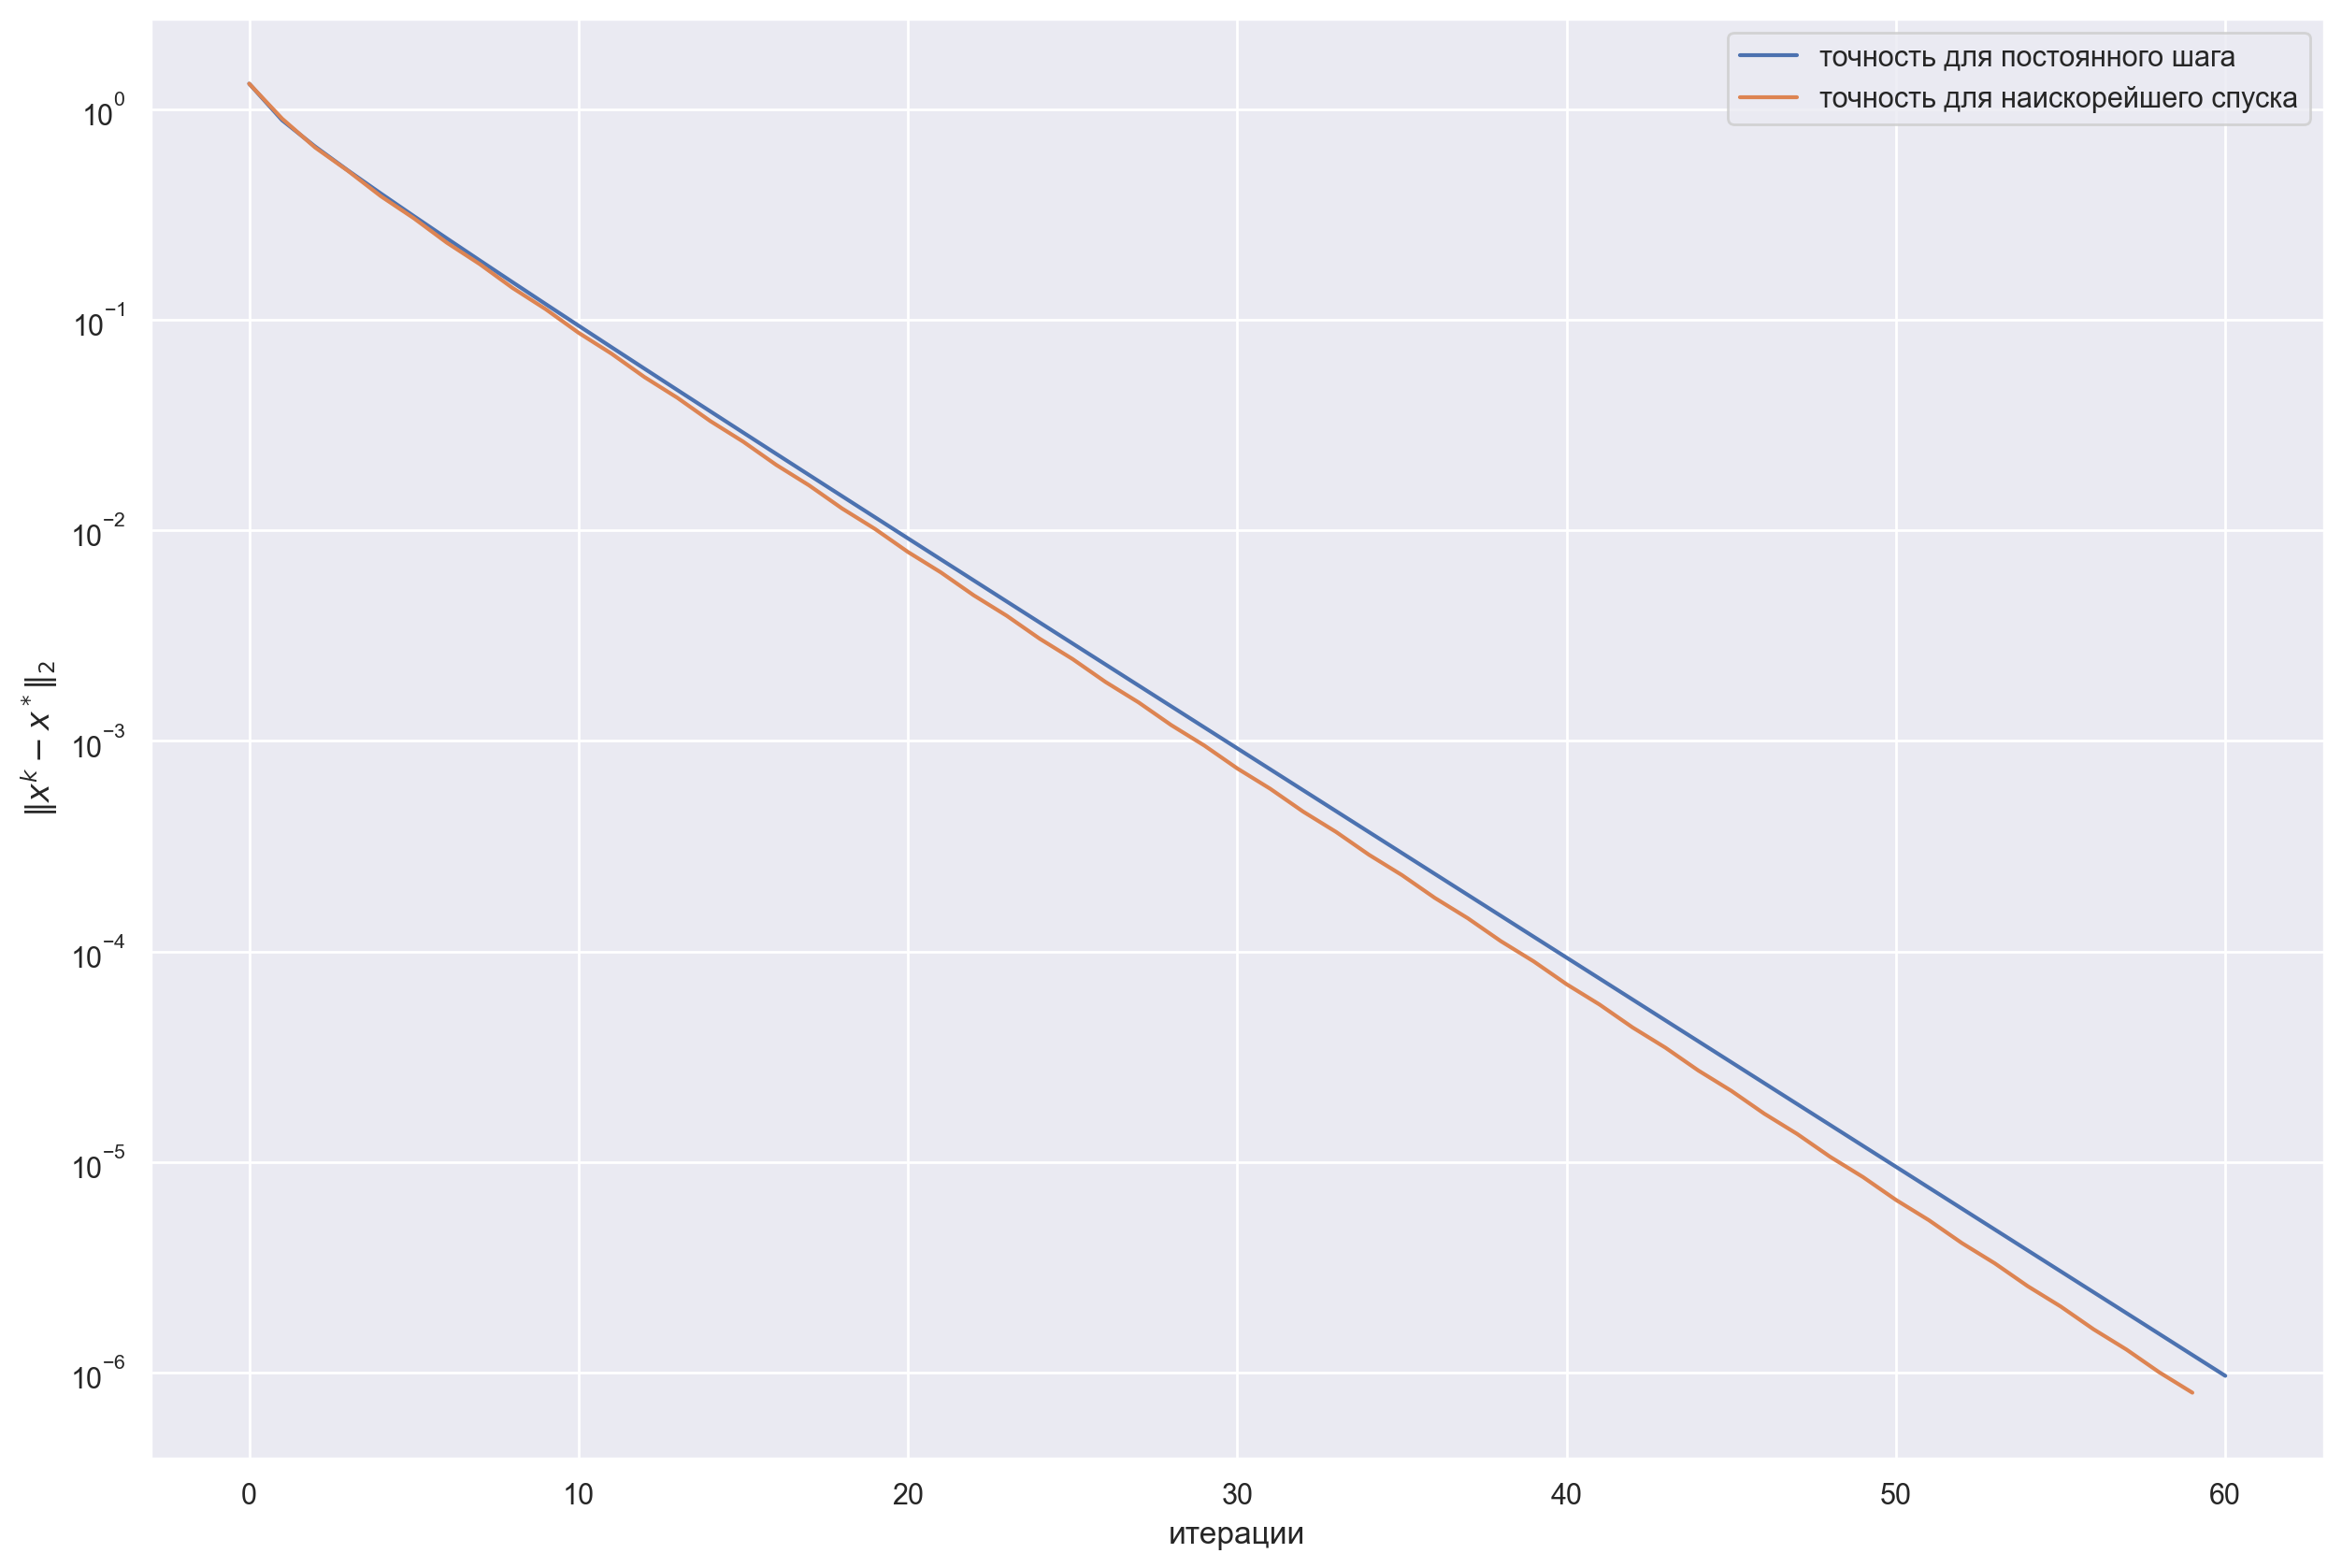

In [90]:
# Ваше решение (Code)

x_0 = np.zeros([d, 1])
x_star = x_min(A, b)

gamma_fix = lambda k : 2 / (L + mu)
x_fix, errors_fix = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma = gamma_fix)
x_fastest, errors_fastest = fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma = gamma_fastest)

iter_fix = len(errors_fix)
iter_fastest = len(errors_fastest)
grid_fix = np.arange(iter_fix)
grid_fastest = np.arange(iter_fastest)

plt.figure(figsize = (15, 10))
plt.plot(grid_fix, errors_fix, label = r"точность для постоянного шага")
plt.plot(grid_fastest, errors_fastest, label = r"точность для наискорейшего спуска")

plt.xlabel("итерации")
plt.ylabel(r"$\|x^k - x^*\|_2$")
plt.legend()
plt.yscale("log")


Как мы видим метод наискорейшего спуска вместе с методом с фиксированным шагом почти не отличимы (на глаз)

__г) (2 балла)__ И последним способом подбора шага станет шаг Поляка—Шора: $\gamma_k = \frac{f \left(x^k\right) - f^*}{\alpha \|\nabla f\left(x^k\right)\|^2_2}$, где $\alpha$ нужно подобрать отдельно.

In [91]:
def schor_gradient_descent(A, b, grad, criterion, x_0, x_star, epsilon=1e-6, max_iter=1000, **params):
    """
    Реализация градиентного спуска с шагом Поляка—Шора для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы.
        b (np.array): Вектор линейной части.
        grad (Callable): Функция для вычисления градиента.
        criterion (Callable): Функция для вычисления критерия сходимости.
        x_0 (np.array): Начальная точка.
        x_star (np.array): Точное решение.
        epsilon (float): Точность сходимости (по умолчанию 1e-6).
        max_iter (int): Максимальное число итераций (по умолчанию 1000).
        **params: Именованные гиперпараметры метода
            params['gamma'](A, b, grad, x, x_star, alpha) — значение шага на итерации k.
            params['alpha'] — параметр шага Поляка—Шора.

    Возвращает:
        x (np.array): Найденное решение.
        errors (list): Список значений критерия сходимости на каждой итерации.
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]

    alpha = params['alpha']
    
    for k in range(max_iter):
        
        # YOUR CODE HERE
        gamma = params["gamma"](A, b, grad, x, x_star, alpha)
        x -= gamma * grad(x, A, b)

        error = criterion(x, x_star)
        errors.append(error)
        
        if error < epsilon:
            break
            
    return x, errors

In [92]:
def gamma_schor(A, b, grad, x, x_star, alpha):
    """
    Вычисляет шаг gamma_k = (f(x^k) - f(x*))/(a||∇f(x_k)||)

    Параметры:
        A (np.array): Матрица квадратичной формы.
        b (np.array): Вектор линейной части.
        grad (Callable): Функция для вычисления градиента.
        x (np.array): Точка.
        x_star (np.array): Точное решение.
        gamma (float): Параметр шага Поляка—Шора.

    Возвращает:
        gamma (float): Найденное решение.
    """
    # YOUR CODE HERE

    fx_k = 0.5 * x.T@A@x - b.T@x
    fx_star = 0.5 * x_star.T@A@x_star - b.T@x_star
    norm_grad = np.linalg.norm(grad(x, A, b))

    numerator = fx_k - fx_star
    denominator = alpha * norm_grad**2

    return numerator / denominator

Рассмотрите следующие значения для $\alpha$: 0.8, 1.0, 1.2, 1.5 и 2.0. Постройте сравнительные графики, найдите значение $\alpha$, при котором достигается наилучшая сходимость.

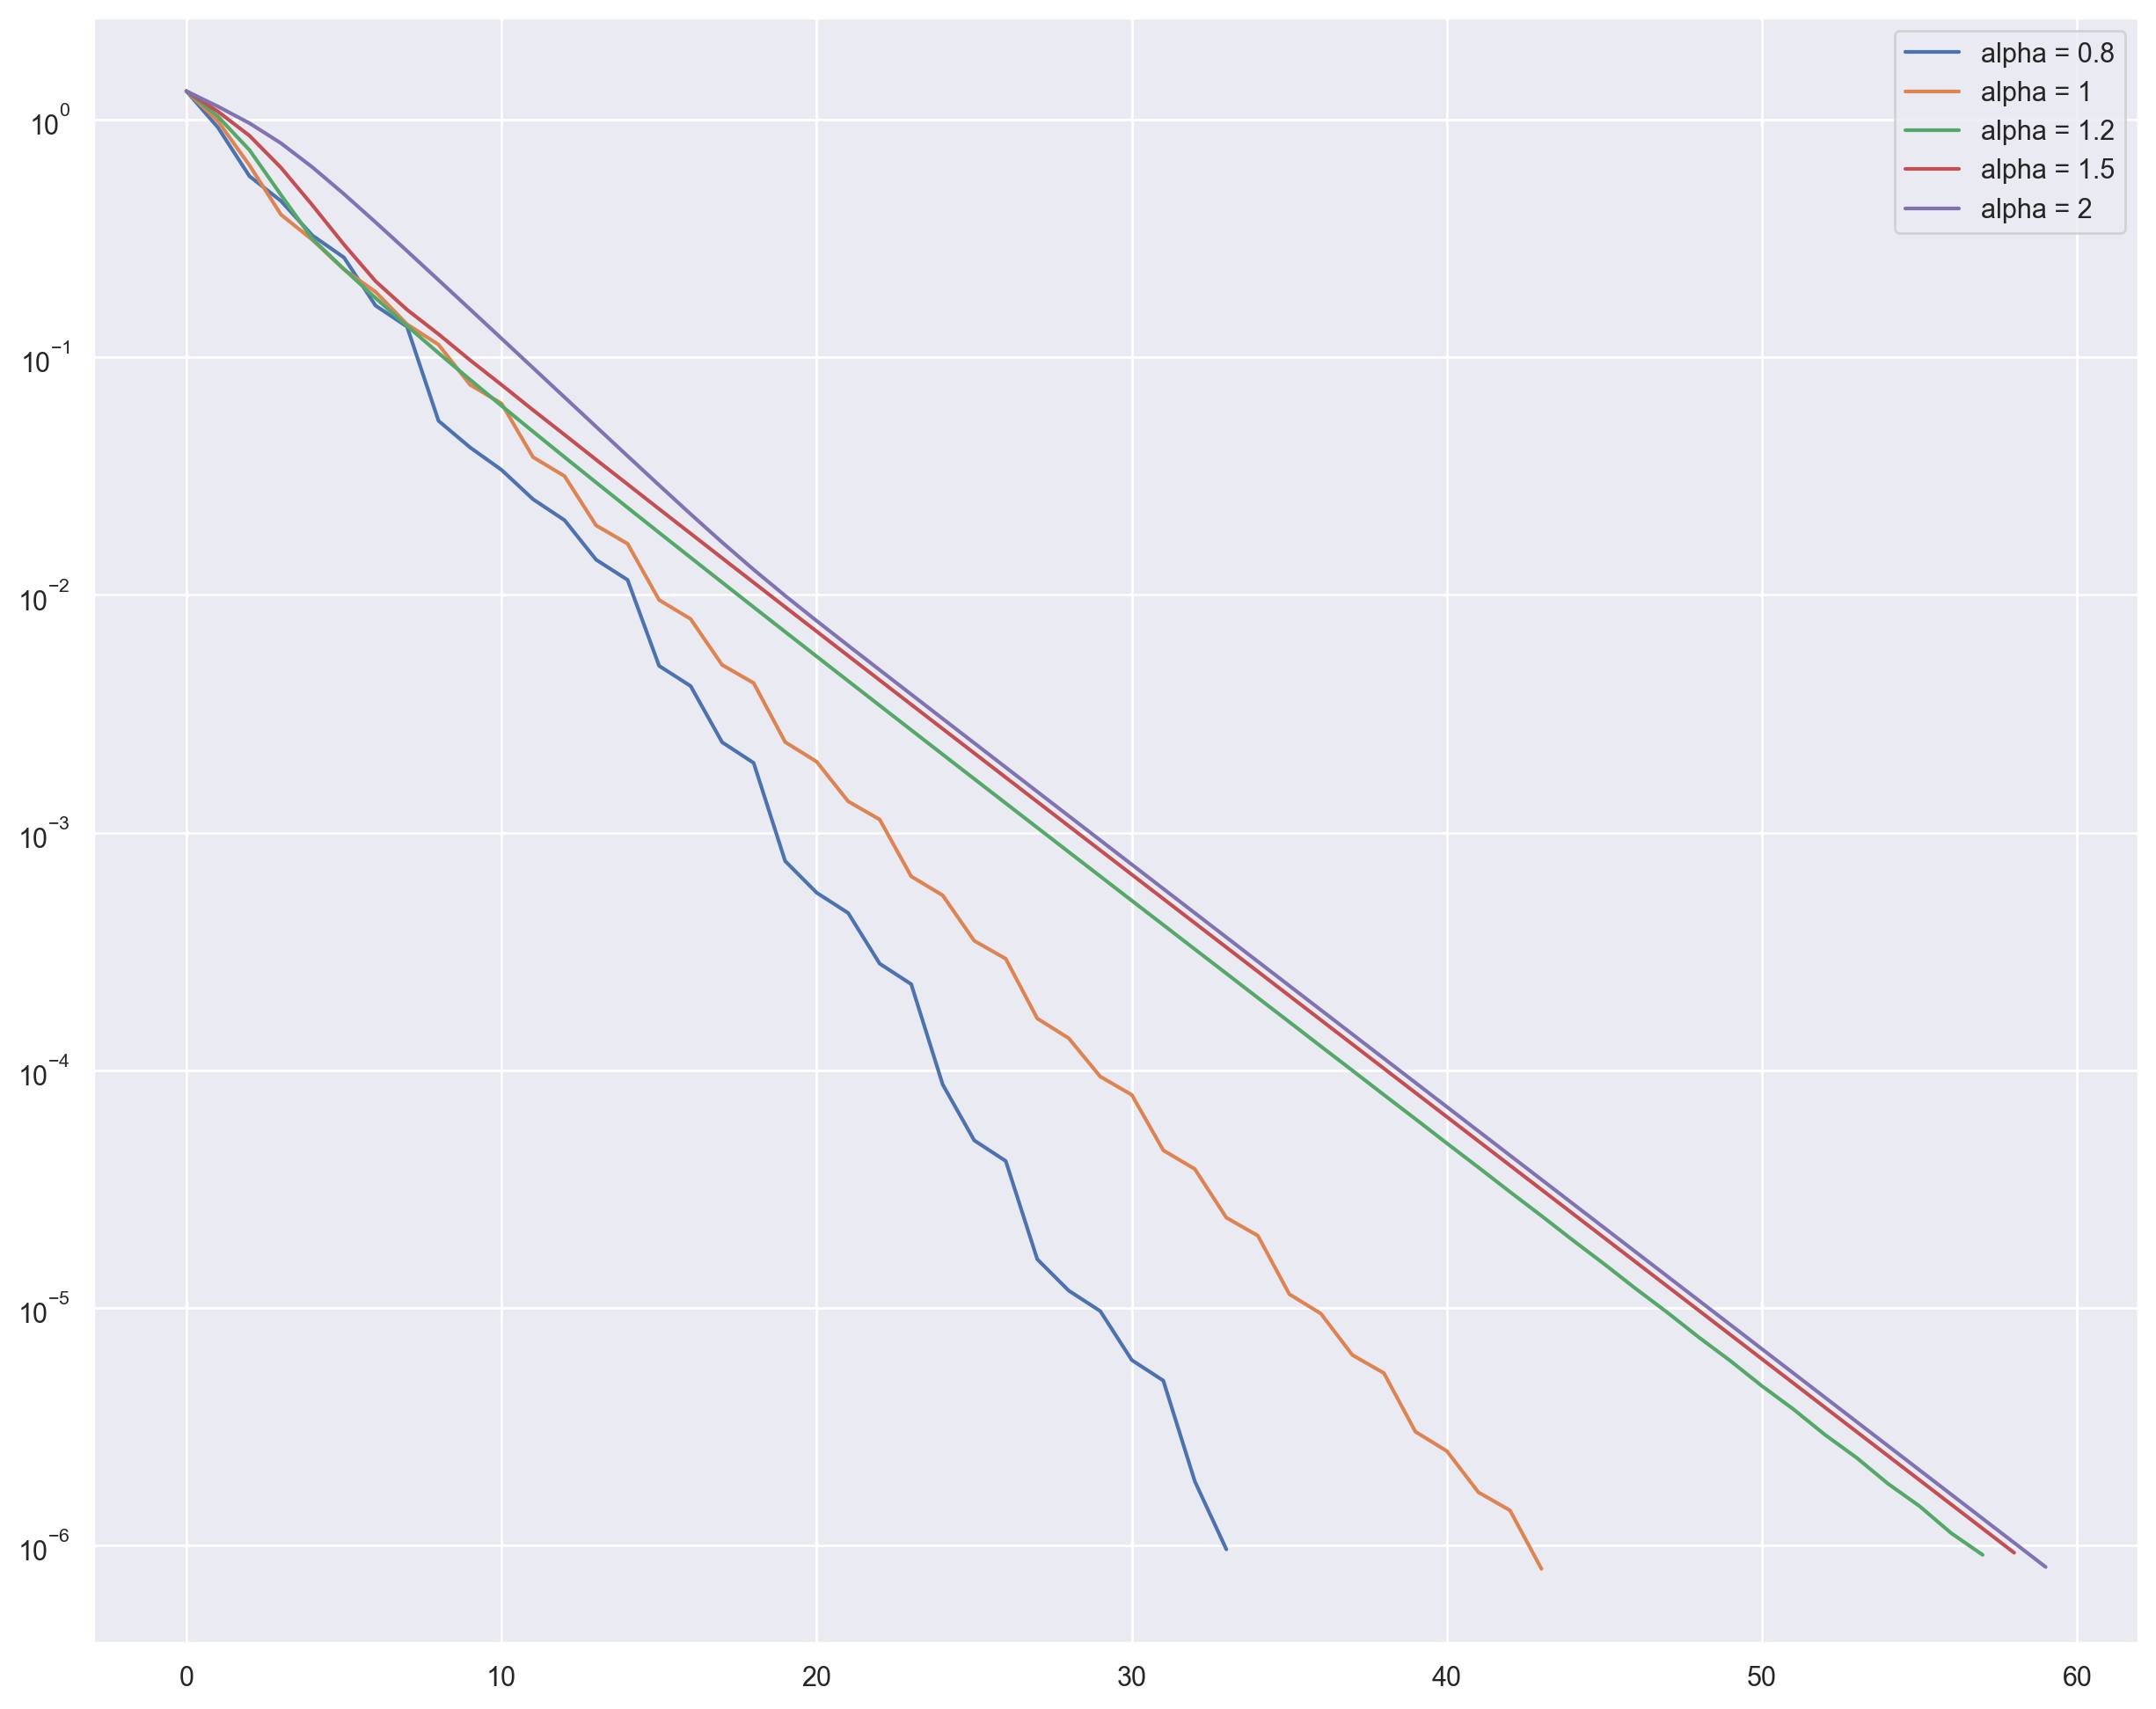

In [93]:
# Ваше решение (Code)

alpha_list = [0.8, 1, 1.2, 1.5, 2]
plt.figure(figsize = (15, 12))
for alpha in alpha_list:
  x_schor, errors_schor = schor_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_schor, alpha=alpha)
  iter_count = len(errors_schor)
  grid = np.arange(iter_count)
  plt.plot(grid, errors_schor, label = f"alpha = {alpha}")

plt.legend()
plt.yscale("log")

Быстрее всех сходится метод с $\alpha =$ 0.8 

__д) (2 балла)__ Финал — постройте итоговый сравнительный график, на котором должны быть лучшие представители для

1. Постоянного шага;

2. Шага наискорейшего спуска;

3. Шага Поляка—Шора.

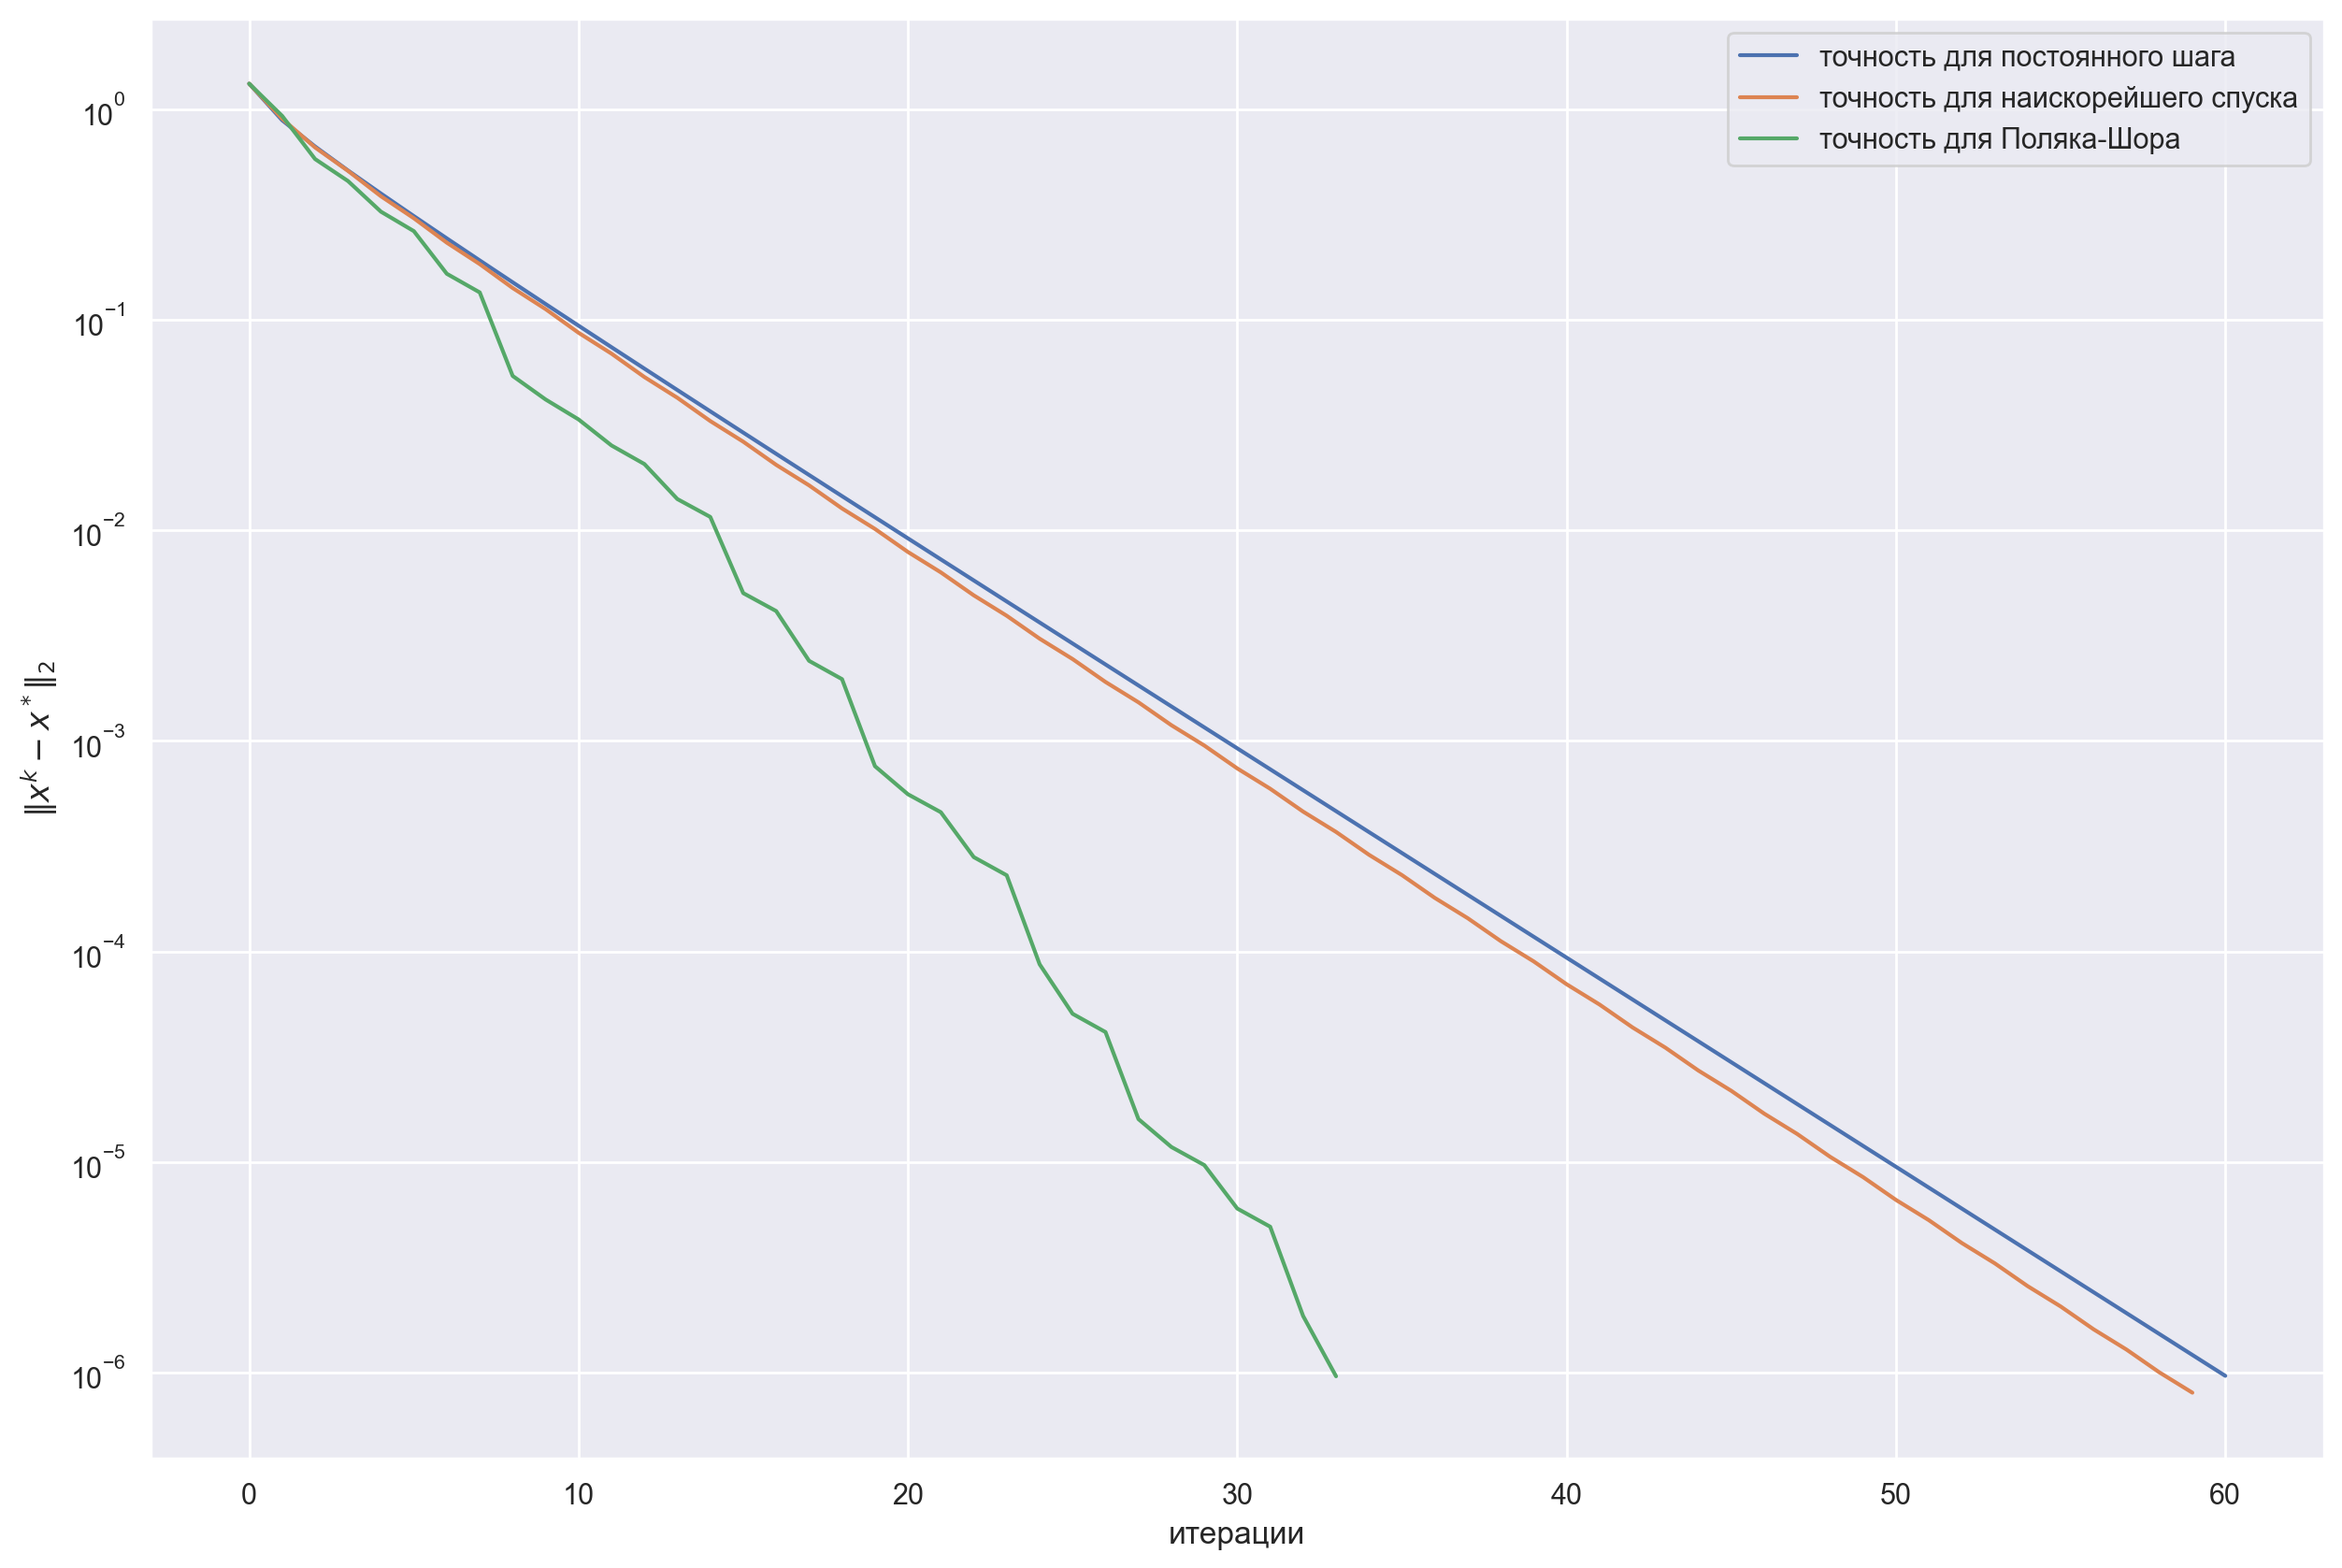

In [94]:
# Ваше решение (Code)

gamma_fix = lambda k : 2 / (L + mu)
alpha_schor = 0.8
x_fix, errors_fix = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma = gamma_fix)
x_fastest, errors_fastest = fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma = gamma_fastest)
x_schor, errors_schor = schor_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_schor, alpha=alpha_schor)

iter_fix = len(errors_fix)
iter_fastest = len(errors_fastest)
iter_schor = len(errors_schor)
grid_fix = np.arange(iter_fix)
grid_fastest = np.arange(iter_fastest)
grid_schor = np.arange(iter_schor)

plt.figure(figsize = (15, 10))
plt.plot(grid_fix, errors_fix, label = r"точность для постоянного шага")
plt.plot(grid_fastest, errors_fastest, label = r"точность для наискорейшего спуска")
plt.plot(grid_schor, errors_schor, label = r"точность для Поляка-Шора")

plt.xlabel("итерации")
plt.ylabel(r"$\|x^k - x^*\|_2$")
plt.legend()
plt.yscale("log")


Объясните полученные результаты. 

#### Ваше решение (Markdown)

как мы можем наблюдать, методы с наискорейшим спуском и оптимальным постоянным шагом работают почти одинаково - возможно это особенности нами поставленной задаи (она квадратична и задается всего лишь перемножением переменных векторов с константными матрицой и вектором)

но самое главное : метод Поляка-Шора показывает лучшую скорость сходимости по сравнению с предыдущими методами.

мне кажется что информация которой обладает шаг Поляка-Шора в виде растояния до миниму сильно помогает контролировать размер шага, ведь если мы далеки от решения, шаг можно делать большим, а если близки то маленьким.
